In [1]:
import pandas as pd

df = pd.read_csv("../data/Mall_Customers.csv")
df.head()


ModuleNotFoundError: No module named 'pandas'

In [2]:
!pip install pandas



   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.7 MB 9.3 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.7 MB 10.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.7 MB 10.7 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 10.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

df = pd.read_csv("../data/Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


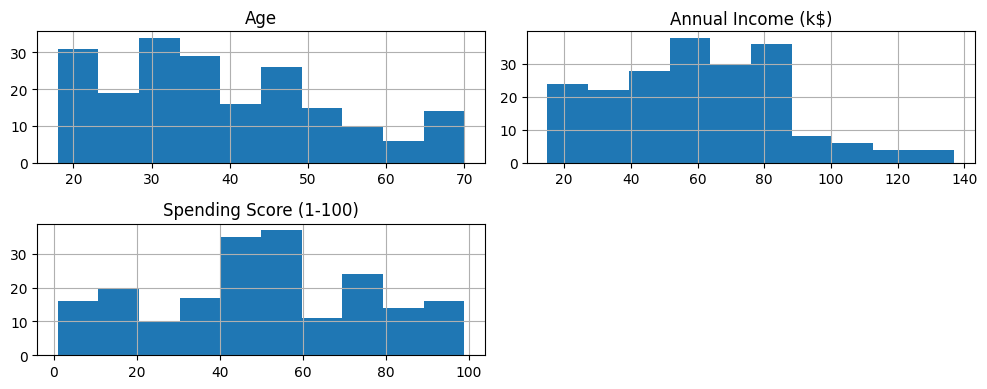

In [5]:
import matplotlib.pyplot as plt

df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(
    bins=10,
    figsize=(10, 4)
)

plt.tight_layout()
plt.show()


In [6]:
# 4.1 Selección de variables
cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[cols].copy()

X.head()


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [7]:
# 4.2 Escalado de variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

ModuleNotFoundError: No module named 'sklearn'

In [8]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.0 MB 7.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.0 MB 8.3 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 9.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.3 MB 11.6 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/36.3 MB 10.8 MB/s eta 0:00:03
   ------- -------------------------------- 6.6/36.3 MB 10.3 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.3 MB 10.4 MB/s eta 0:00:03
   ------------ --------------------------- 11.0/36.3 MB 10.5 MB/s eta 0:00:03
   -------------- ------------------------- 13.1/36.3 MB 10.5 MB/s eta 0:00:03
   --------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# 4.2 Escalado de variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [10]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled, columns=cols)
X_scaled_df.head()


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [11]:
# 4.3 Verificación + export del dataset preprocesado
X_scaled_df.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,7.284319e-01,6.656748e-01,8.851316e-01
max,2.235532e+00,2.917671e+00,1.894492e+00


In [12]:
# dejarmeos guardado el csv, escalonado para usos futuros en caso de que sea necesario
X_scaled_df.to_csv("../data/mall_customers_preprocessed.csv", index=False)


In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled_df)

clusters_kmeans[:10]


array([2, 2, 3, 2, 2, 2, 3, 2, 0, 2], dtype=int32)

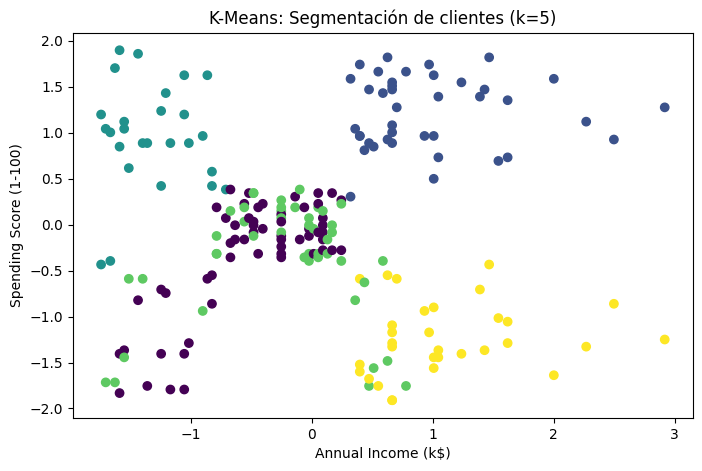

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(
    X_scaled_df["Annual Income (k$)"],
    X_scaled_df["Spending Score (1-100)"],
    c=clusters_kmeans
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means: Segmentación de clientes (k=5)")
plt.show()


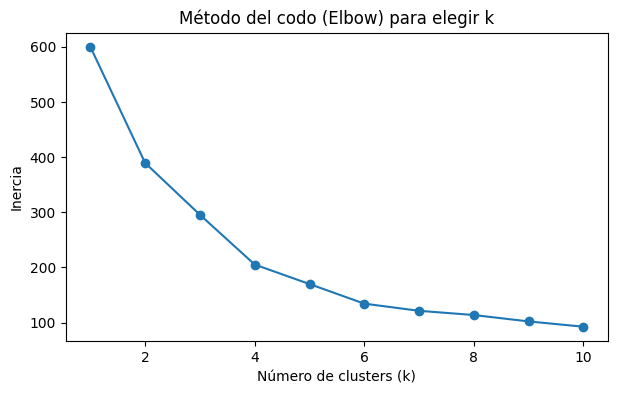

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo (Elbow) para elegir k")
plt.show()


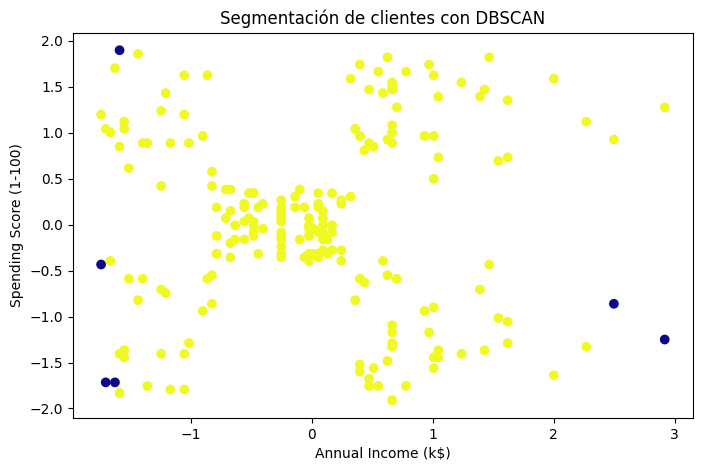

In [16]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=0.8, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled_df)

plt.figure(figsize=(8,5))
plt.scatter(
    X_scaled_df["Annual Income (k$)"],
    X_scaled_df["Spending Score (1-100)"],
    c=clusters_dbscan,
    cmap="plasma"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Segmentación de clientes con DBSCAN")
plt.show()


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled_df)


In [18]:
import numpy as np
import pandas as pd

labels = clusters_dbscan
summary_dbscan = pd.Series(labels).value_counts().sort_index()
summary_dbscan


-1      6
 0    194
Name: count, dtype: int64